In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

# Generate 24h of activity data sampled every 10 minutes
# 24h * 60min/h / 10min = 144 points
n_points = 24 * 60 // 10
minutes = np.arange(n_points) * 10

# Activity schedule by minute-of-day
# Sleep: 11pm-7am => 0.5
# Resting: 1h around lunch, 1h 5pm-6pm, 2h 9pm-10pm => 0.9
# Moving: all other active hours => 2.0
# Noise: 0.3 Gaussian noise

def activity_level(minute_of_day: int) -> float:
    # minute_of_day in [0, 1439]
    h = minute_of_day // 60
    m = minute_of_day % 60
    total_min = h * 60 + m

    sleep = (total_min >= 23 * 60) or (total_min < 7 * 60)
    lunch_rest = (7 * 60 <= total_min < 8 * 60) or (12 * 60 <= total_min < 13 * 60)
    late_afternoon_rest = (17 * 60 <= total_min < 18 * 60)
    evening_rest = (21 * 60 <= total_min < 23 * 60)

    if sleep:
        return 0.5
    if lunch_rest or late_afternoon_rest or evening_rest:
        return 0.9
    return 2.0

values = np.array([activity_level(m) for m in minutes], dtype=float)
noise = np.random.default_rng(42).normal(0, 0.3, size=len(values))
values = values + noise

# Keep values within a reasonable range for the signal
values = np.clip(values, 0.0, 3.0)

# Create DataFrame with timestamps and movement values
start = pd.Timestamp("2026-01-01 00:00:00")
timestamps = [start + pd.Timedelta(minutes=int(m)) for m in minutes]

df = pd.DataFrame({
    "time": timestamps,
    "minute_of_day": minutes,
    "movement": values,
})

# Save to CSV in the same folder as this notebook
output_path = Path.cwd() / "movement.csv"
df.to_csv(output_path, index=False)

print(f"Saved {len(df)} rows to {output_path}")
df.head()

Saved 144 rows to c:\Users\mv68b\OneDrive - University of Glasgow\Teaching\ENG3090\lectures\data\movement.csv


,time,minute_of_day,movement
0,2026-01-01 00:00:00,0,0.591415
1,2026-01-01 00:10:00,10,0.188005
2,2026-01-01 00:20:00,20,0.725135
3,2026-01-01 00:30:00,30,0.782169
4,2026-01-01 00:40:00,40,0.000000


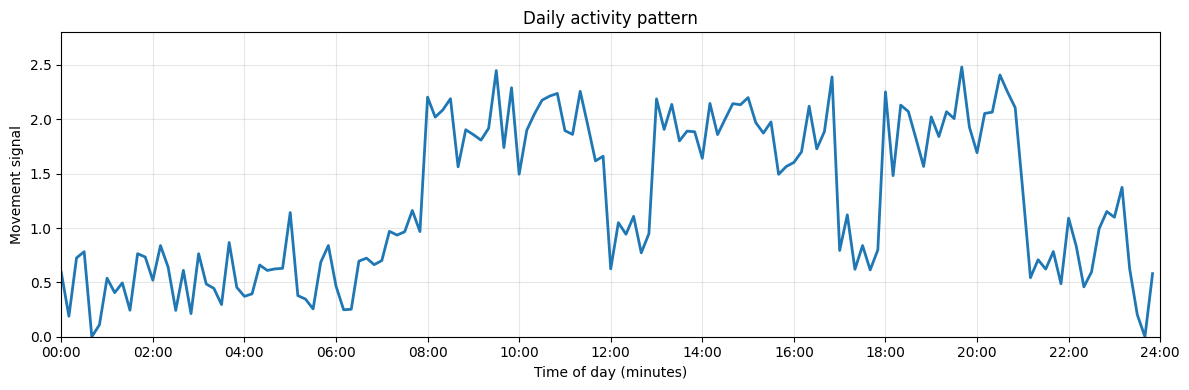

In [4]:
import matplotlib.pyplot as plt

bands = False

# Plot movement as a function of time of day
plt.figure(figsize=(12, 4))
plt.plot(df["minute_of_day"], df["movement"], color="tab:blue", linewidth=2)

# Shade key rest periods for visual interpretation
sleep_periods = [
    (0, 7 * 60),
    (23 * 60, 24 * 60)
]
rest_periods = [
    (12 * 60, 13 * 60),
    (17 * 60, 18 * 60),
    (21 * 60, 23 * 60),
]
if bands:
    for start, end in sleep_periods:
        plt.axvspan(start, end, color="cyan", alpha=0.15)
    for start, end in rest_periods:
        plt.axvspan(start, end, color="gray", alpha=0.15)

plt.xlabel("Time of day (minutes)")
plt.ylabel("Movement signal")
plt.title("Daily activity pattern")
plt.xlim(0, 24 * 60)
plt.ylim(0, 2.8)
plt.xticks(np.arange(0, 24 * 60 + 1, 120), [f"{h:02d}:00" for h in range(0, 25, 2)])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


                  time  minute_of_day  movement
0  2026-01-01 00:00:00              0  0.591415
1  2026-01-01 00:10:00             10  0.188005
2  2026-01-01 00:20:00             20  0.725135
3  2026-01-01 00:30:00             30  0.782169
4  2026-01-01 00:40:00             40  0.000000
Above threshold T=1.0: 76 points (52.8%)


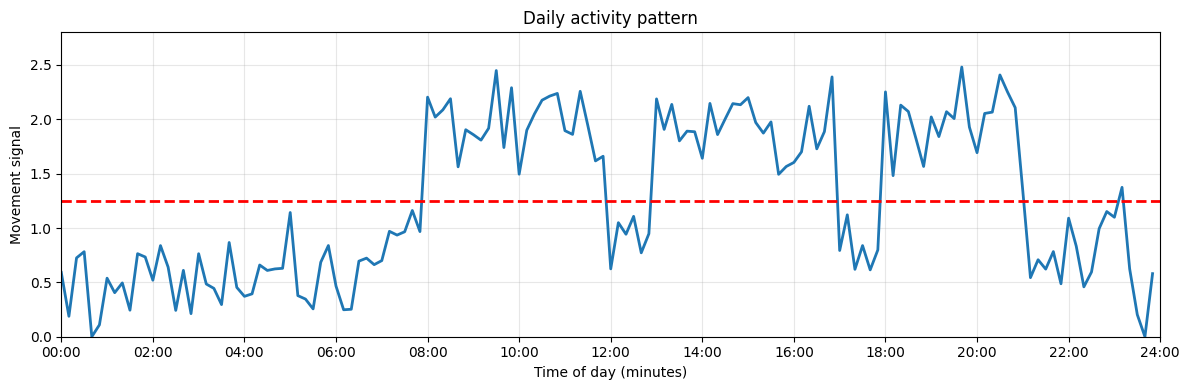

In [23]:
import pandas as pd

# Read the generated CSV back into a DataFrame
movement = pd.read_csv(Path.cwd() / 'movement.csv')

# Show first rows to confirm the file content
a = movement.head()
print(a)

def howmany(data, T):
    """Return number and percentage of samples above threshold T."""
    data = np.asarray(data, dtype=float)
    above = data > T
    count = int(np.sum(above))
    percentage = 100.0 * count / len(data)
    return count, percentage

# Example usage with the movement threshold
count, percentage = howmany(movement['movement'], 1.0)
print(f'Above threshold T=1.0: {count} points ({percentage:.1f}%)')

plt.figure(figsize=(12, 4))
plt.plot(df["minute_of_day"], df["movement"], color="tab:blue", linewidth=2)
plt.axhline(1.25, color='red', linestyle='--', linewidth=2, label=f'Ideal no-noise value: {ideal_pct:.1f}%')

plt.xlabel("Time of day (minutes)")
plt.ylabel("Movement signal")
plt.title("Daily activity pattern")
plt.xlim(0, 24 * 60)
plt.ylim(0, 2.8)
plt.xticks(np.arange(0, 24 * 60 + 1, 120), [f"{h:02d}:00" for h in range(0, 25, 2)])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


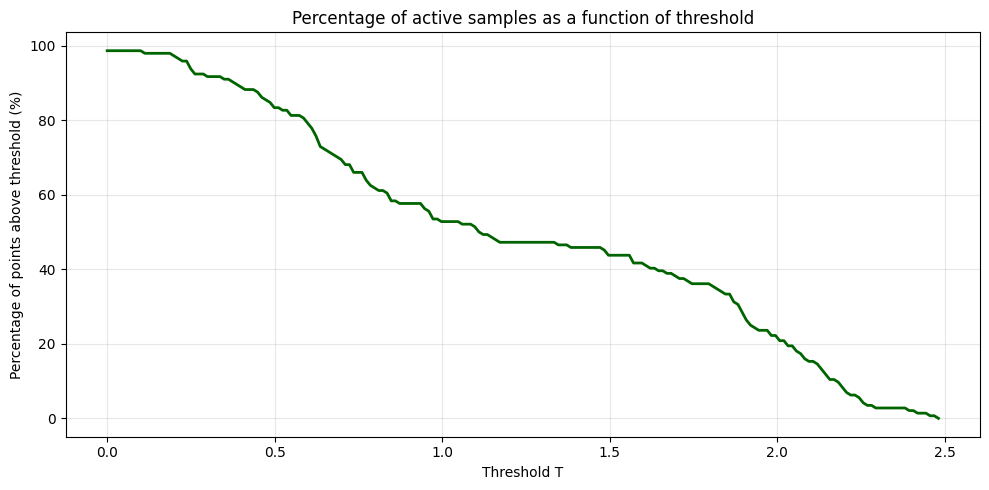

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Sweep threshold T from 0 to the maximum movement value
T_values = np.linspace(0, movement['movement'].max(), 200)
percentages = []

for T in T_values:
    _, pct = howmany(movement['movement'], T)
    percentages.append(pct)

plt.figure(figsize=(10, 5))
plt.plot(T_values, percentages, color='darkgreen', linewidth=2)
plt.xlabel('Threshold T')
plt.ylabel('Percentage of points above threshold (%)')
plt.title('Percentage of active samples as a function of threshold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


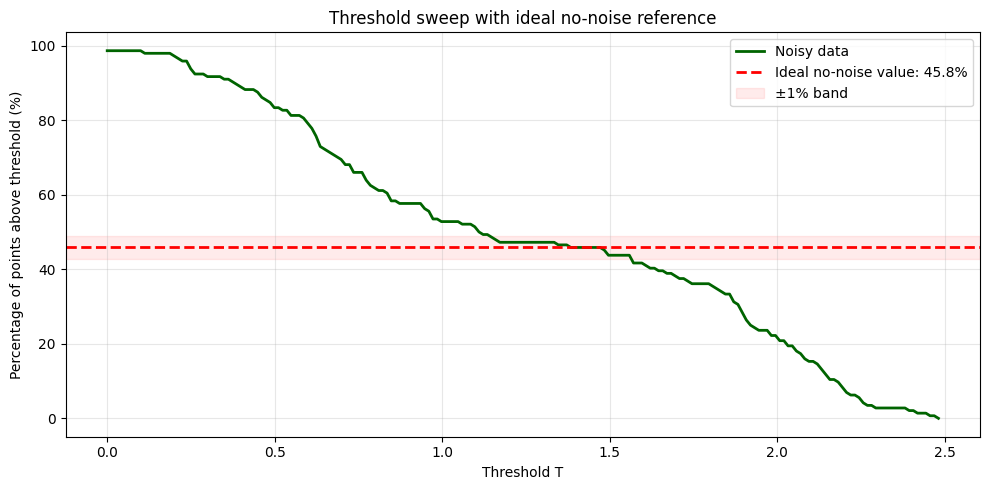

Ideal no-noise active points above T=1.0: 66 / 144 = 45.8%


In [12]:
# True signal without noise: use the original activity levels before Gaussian noise was added
base_signal = np.array([activity_level(m) for m in minutes], dtype=float)
# Active points are values above the chosen threshold T. Here, the ideal threshold is 1.0
ideal_threshold = 1.0
ideal_count, ideal_pct = howmany(base_signal, ideal_threshold)

# Add the reference horizontal line to the threshold plot
band = 3.0
plt.figure(figsize=(10, 5))
plt.plot(T_values, percentages, color='darkgreen', linewidth=2, label='Noisy data')
plt.axhline(ideal_pct, color='red', linestyle='--', linewidth=2, label=f'Ideal no-noise value: {ideal_pct:.1f}%')
plt.axhspan(ideal_pct - band, ideal_pct + band, color='red', alpha=0.08, label='±1% band')
plt.xlabel('Threshold T')
plt.ylabel('Percentage of points above threshold (%)')
plt.title('Threshold sweep with ideal no-noise reference')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f'Ideal no-noise active points above T={ideal_threshold}: {ideal_count} / {len(base_signal)} = {ideal_pct:.1f}%')


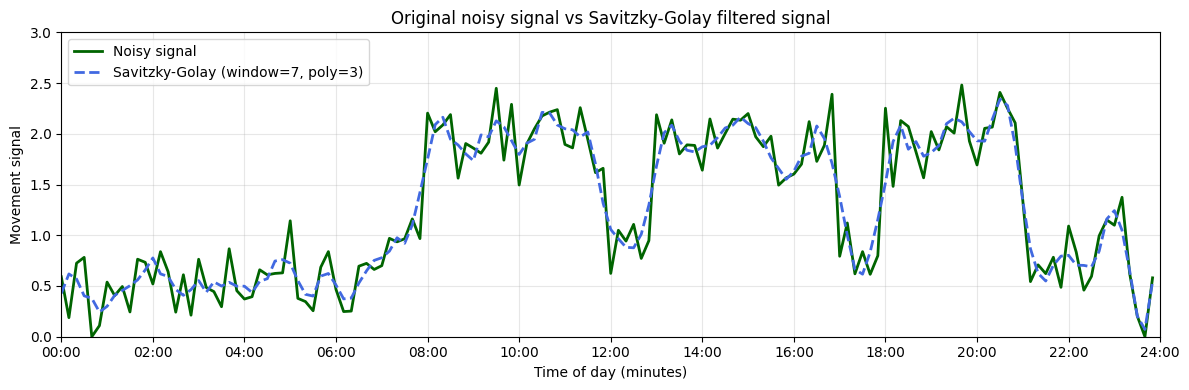

In [29]:
from scipy.signal import savgol_filter

# Smooth the noisy signal with a Savitzky-Golay filter to show denoising effect
window_length = 7
polyorder = 3
filtered = savgol_filter(movement['movement'].to_numpy(), window_length=window_length, polyorder=polyorder, mode='interp')

# Plot original noisy signal and Savitzky-Golay filtered version
plt.figure(figsize=(12, 4))
plt.plot(df['minute_of_day'], df['movement'], color='darkgreen', linewidth=2, label='Noisy signal')
plt.plot(df['minute_of_day'], filtered, color='royalblue', linewidth=2, linestyle='--', label=f'Savitzky-Golay (window={window_length}, poly={polyorder})')
plt.xlabel('Time of day (minutes)')
plt.ylabel('Movement signal')
plt.title('Original noisy signal vs Savitzky-Golay filtered signal')
plt.xlim(0, 24 * 60)
plt.ylim(0, 3.0)
plt.xticks(np.arange(0, 24 * 60 + 1, 120), [f'{h:02d}:00' for h in range(0, 25, 2)])
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


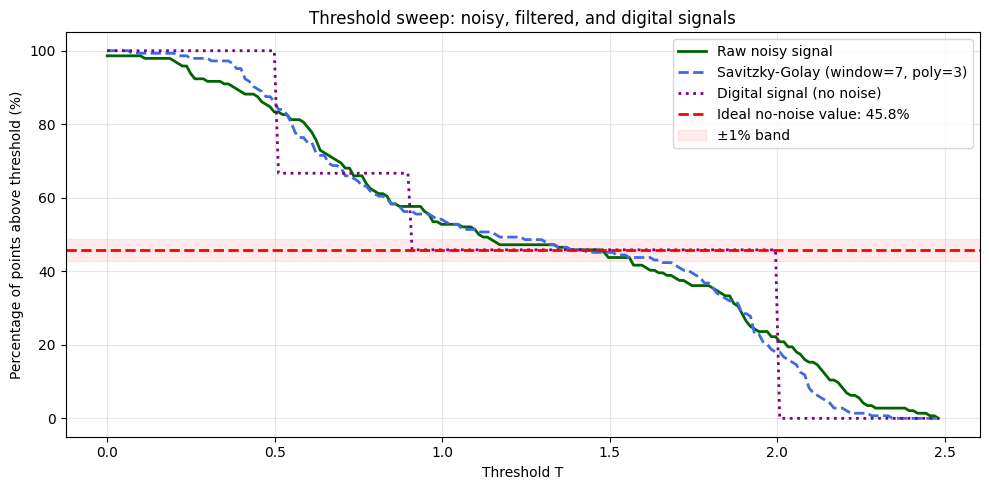

Filtered signal above threshold T=1.0: 78 / 144 = 54.2%
Digital signal above threshold T=1.0: 66 / 144 = 45.8%


In [20]:
# Digital (no-noise) threshold curve: P(T) for the clean activity signal
clean_percentages = []
for T in T_values:
    _, pct = howmany(base_signal, T)
    clean_percentages.append(pct)

# Compare raw noisy, filtered, and digital-only curves
plt.figure(figsize=(10, 5))
plt.plot(T_values, percentages, color='darkgreen', linewidth=2, label='Raw noisy signal')
plt.plot(T_values, filtered_percentages, color='royalblue', linewidth=2, linestyle='--', label=f'Savitzky-Golay (window={window_length}, poly={polyorder})')
plt.plot(T_values, clean_percentages, color='purple', linewidth=2, linestyle=':', label='Digital signal (no noise)')
plt.axhline(ideal_pct, color='red', linestyle='--', linewidth=2, label=f'Ideal no-noise value: {ideal_pct:.1f}%')
plt.axhspan(ideal_pct - band, ideal_pct + band, color='red', alpha=0.08, label='±1% band')
plt.xlabel('Threshold T')
plt.ylabel('Percentage of points above threshold (%)')
plt.title('Threshold sweep: noisy, filtered, and digital signals')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f'Filtered signal above threshold T={ideal_threshold}: {howmany(filtered, ideal_threshold)[0]} / {len(filtered)} = {howmany(filtered, ideal_threshold)[1]:.1f}%')
print(f'Digital signal above threshold T={ideal_threshold}: {howmany(base_signal, ideal_threshold)[0]} / {len(base_signal)} = {howmany(base_signal, ideal_threshold)[1]:.1f}%')

In [31]:
print(howmany(df['movement'], 1.25))

(68, 47.22222222222222)
